In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer

In [13]:
df = pd.read_csv("best_data.csv")

In [14]:
df.shape

(21928, 51)

In [15]:
df.columns

Index(['Latitude_Degrees', 'Longitude_Degrees', 'Distance_to_Shore',
       'Turbidity', 'Cyclone_Frequency', 'Depth_m', 'Percent_Bleaching',
       'ClimSST', 'Temperature_Kelvin', 'Temperature_Mean',
       'Temperature_Minimum', 'Temperature_Maximum',
       'Temperature_Kelvin_Standard_Deviation', 'Windspeed', 'SSTA',
       'SSTA_Standard_Deviation', 'SSTA_Minimum', 'SSTA_Maximum',
       'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation',
       'SSTA_FrequencyMax', 'SSTA_FrequencyMean', 'SSTA_DHW',
       'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA',
       'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Maximum', 'TSA_Mean',
       'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax',
       'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation',
       'TSA_DHWMax', 'TSA_DHWMean', 'Month_1', 'Month_2', 'Month_3', 'Month_4',
       'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 'Month_10',
       'Month_11', 'Month_12'],


# PCA

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [17]:
X = df.drop("Percent_Bleaching", axis=1)
Y = df["Percent_Bleaching"]

In [18]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [19]:
X_train_raw_month, X_test_raw_month = X_train_raw[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy(), X_test_raw[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy()

X_train_raw_fe, X_test_fe = X_train_raw[['Latitude_Degrees', 'Longitude_Degrees', 'Depth_m', 'ClimSST', 'SSTA']].copy(), \
       X_test_raw[['Latitude_Degrees', 'Longitude_Degrees', 'Depth_m', 'ClimSST', 'SSTA']].copy()


X_train_raw = X_train_raw.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12'])
X_test_raw = X_test_raw.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12'])

In [20]:
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp = imputer.transform(X_test_raw)

# SEPARATE imputer for FE — and keep as DataFrame
fe_imputer = SimpleImputer(strategy='median')
X_train_raw_fe = pd.DataFrame(
    fe_imputer.fit_transform(X_train_raw_fe),
    columns=X_train_raw_fe.columns,
    index=X_train_raw_fe.index
)
X_test_fe = pd.DataFrame(
    fe_imputer.transform(X_test_fe),
    columns=X_test_fe.columns,
    index=X_test_fe.index
)

scaler = StandardScaler()
X_train_ss = scaler.fit_transform(X_train_imp)
X_test_ss = scaler.transform(X_test_imp)

In [21]:
X_train_ss.shape

(17542, 38)

In [22]:
pca = PCA(n_components=0.75)
X_train_pca = pca.fit_transform(X_train_ss)
X_test_pca = pca.transform(X_test_ss)

In [23]:
X_train_pca_df = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])])
X_test_pca_df = pd.DataFrame(X_test_pca, columns=[f'PC{i+1}' for i in range(X_test_pca.shape[1])])

X_train_raw_month = X_train_raw_month.reset_index(drop=True)
X_test_raw_month = X_test_raw_month.reset_index(drop=True)

X_train_raw_fe = X_train_raw_fe.reset_index(drop=True)
X_test_fe = X_test_fe.reset_index(drop=True)

X_train_pca = pd.concat([X_train_pca_df, X_train_raw_month, X_train_raw_fe], axis=1)
X_test_pca  = pd.concat([X_test_pca_df,  X_test_raw_month,  X_test_fe],       axis=1)

In [24]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Start

In [25]:
hgb_model = HistGradientBoostingRegressor(
    max_iter=394,
    max_depth=15,
    learning_rate=0.0829,
    min_samples_leaf=16,
    l2_regularization=0.094,
    random_state=42
)
# {'max_iter': 394, 'max_depth': 15, 'learning_rate': 0.08291466086400667, 'min_samples_leaf': 16, 'l2_regularization': 0.09425830628658521}

et_model = ExtraTreesRegressor(
    n_estimators=246,
    max_depth=34,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

# {'n_estimators': 246, 'max_depth': 34, 'min_samples_leaf': 1, 'max_features': 'sqrt'}

rf_model = RandomForestRegressor(
    n_estimators=165, 
    max_depth=28, 
    min_samples_split =  2,
    min_samples_leaf=1,
    max_features='log2',
    n_jobs=-1, 
    random_state=42
)
# {'n_estimators': 165, 'max_depth': 28, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2'}

In [26]:
voting = VotingRegressor([
    ('hgb', hgb_model),
    ('et',  et_model),
    ('rf',  rf_model)
])

# Train all
hgb_model.fit(X_train_pca, y_train)
et_model.fit(X_train_pca, y_train)
rf_model.fit(X_train_pca, y_train)
voting.fit(X_train_pca, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('hgb', ...), ('et', ...), ...]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.0829
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",394
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",15
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",16


In [27]:
X_test_normal = X_test_pca.copy()

# Noise


=== Latitude_Degrees (perturbed BEFORE PCA) ===
 factor pct_change  HGB_mean  HGB_max  RF_mean  RF_max  ET_mean  ET_max  Voting_mean  Voting_max
  0.100       -90%     4.456   53.211    5.551  67.830    6.291  63.175        4.993      57.478
  0.200       -80%     4.320   47.225    5.366  68.264    5.974  62.890        4.789      53.614
  0.300       -70%     4.457   39.403    5.077  67.993    5.635  61.990        4.645      52.066
  0.400       -60%     4.121   39.610    4.806  66.852    5.306  59.387        4.374      50.443
  0.500       -50%     3.600   41.429    4.413  66.775    4.886  57.500        3.922      48.485
  0.600       -40%     3.400   40.141    4.148  64.694    4.452  55.142        3.635      47.348
  0.700       -30%     3.291   39.779    3.677  61.426    3.901  51.381        3.305      44.433
  0.800       -20%     2.843   36.518    2.939  56.482    3.172  46.320        2.689      41.580
  0.900       -10%     2.052   25.169    2.152  46.707    2.247  37.227       

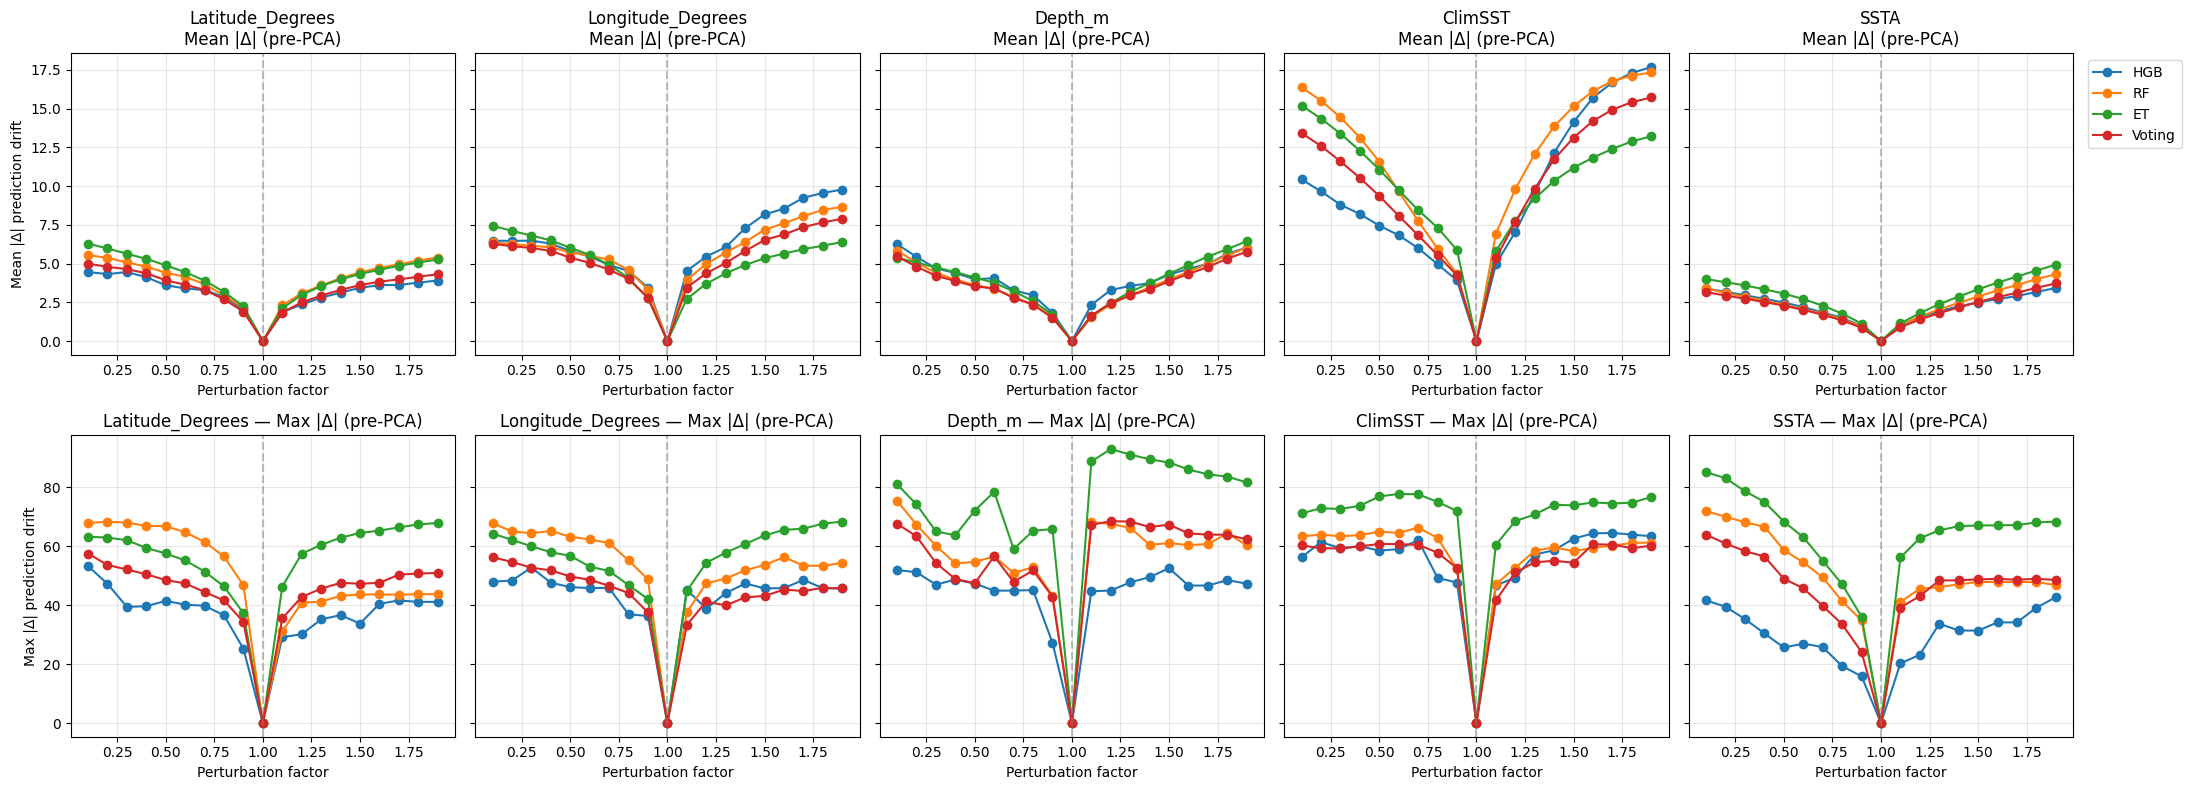


=== ALL features perturbed together (pre-PCA) ===
 factor pct_change  HGB_mean  HGB_max  RF_mean  RF_max  ET_mean  ET_max  Voting_mean  Voting_max
  0.100       -90%    13.744   69.332   15.447  71.209   14.412  78.802       13.967      69.848
  0.200       -80%    12.457   72.438   14.896  70.325   13.874  78.194       13.163      69.545
  0.300       -70%    11.594   68.778   14.353  69.533   13.267  78.995       12.517      67.610
  0.400       -60%    11.102   67.104   13.625  69.800   12.756  81.816       11.926      68.376
  0.500       -50%    10.384   69.854   12.407  72.077   11.995  81.865       10.999      69.079
  0.600       -40%     9.663   75.734   11.201  71.195   11.120  82.772       10.105      72.282
  0.700       -30%     8.937   75.123    9.767  73.523   10.151  88.551        9.074      74.858
  0.800       -20%     8.247   74.534    8.324  79.227    9.178  89.472        8.049      80.977
  0.900       -10%     6.293   69.627    6.510  74.259    7.488  76.363     

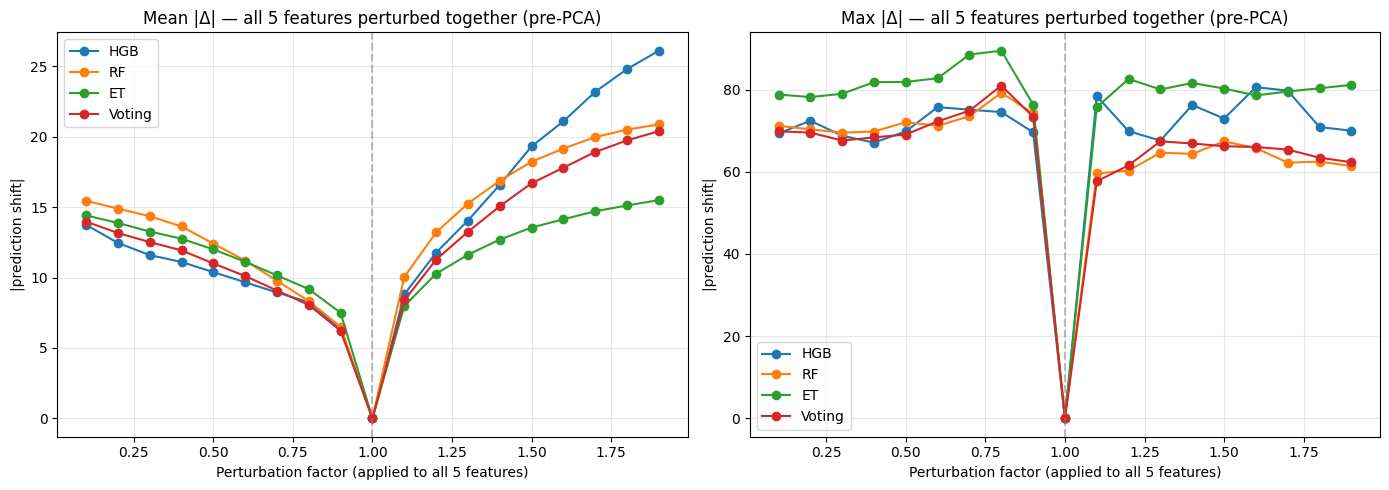

In [28]:
# ─────────────────────────────────────────────────────────────
# Noise robustness — PERTURB BEFORE PCA
# Rebuilds the full feature matrix from raw inputs so the
# perturbation propagates through impute → scale → PCA → reattach.
# ─────────────────────────────────────────────────────────────

models = {
    'HGB    ': hgb_model,
    'RF     ': rf_model,
    'ET     ': et_model,
    'Voting ': voting,
}

features = ['Latitude_Degrees', 'Longitude_Degrees', 'Depth_m', 'ClimSST', 'SSTA']
factors  = np.round(np.arange(0.1, 2.0, 0.1), 2)

# These are the columns that EXIST in X_test_raw (the PCA input block).
# Latitude/Longitude/Depth/ClimSST/SSTA are also in X_test_fe (appended raw block).
pca_input_cols = set(X_test_raw.columns)
fe_block_cols  = set(X_test_fe.columns)


def rebuild_X_test(perturb_cols, factor):
    """Apply factor to perturb_cols in BOTH raw blocks, then rebuild full X."""
    perturb_cols = [perturb_cols] if isinstance(perturb_cols, str) else list(perturb_cols)

    # Copy raw inputs
    raw_pca_block = X_test_raw.copy()
    raw_fe_block  = X_test_fe.copy()

    # Perturb wherever the column lives
    for c in perturb_cols:
        if c in pca_input_cols:
            raw_pca_block[c] = raw_pca_block[c] * factor
        if c in fe_block_cols:
            raw_fe_block[c]  = raw_fe_block[c]  * factor

    # Re-run preprocessing with the SAME fitted objects (transform only, no refit)
    X_imp = imputer.transform(raw_pca_block)
    X_ss  = scaler.transform(X_imp)
    X_pc  = pca.transform(X_ss)

    # Reattach month + FE
    X_pc_df = pd.DataFrame(X_pc, columns=[f'PC{i+1}' for i in range(X_pc.shape[1])])
    return pd.concat(
        [X_pc_df,
         X_test_raw_month.reset_index(drop=True),
         raw_fe_block.reset_index(drop=True)],
        axis=1
    )


# Cache normal predictions (rebuilt at factor=1.0 so the baseline goes through
# the exact same pipeline path — guarantees Δ=0 at factor=1.0)
X_test_baseline = rebuild_X_test([], 1.0)
preds_normal = {name: mdl.predict(X_test_baseline) for name, mdl in models.items()}


def sweep_feature_pre_pca(col_or_cols, factors, label):
    """Perturb before PCA and measure drift across factors."""
    cols = [col_or_cols] if isinstance(col_or_cols, str) else col_or_cols
    rows = []
    for f in factors:
        X_pert = rebuild_X_test(cols, f)
        row = {'factor': f, 'pct_change': f'{(f-1)*100:+.0f}%'}
        for name, mdl in models.items():
            diffs = np.abs(mdl.predict(X_pert) - preds_normal[name])
            row[f'{name.strip()}_mean'] = diffs.mean()
            row[f'{name.strip()}_max']  = diffs.max()
        rows.append(row)
    df = pd.DataFrame(rows)
    df.attrs['label'] = label
    return df


# Sweep each feature individually
results_by_feature = {feat: sweep_feature_pre_pca(feat, factors, feat) for feat in features}

# Print tables
for feat, df in results_by_feature.items():
    print(f"\n=== {feat} (perturbed BEFORE PCA) ===")
    print(df.to_string(index=False, float_format='{:.3f}'.format))


# ───────────────────────────────────────────────
# 2×5 grid: rows = (mean, max), cols = features
# ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharey='row')

for col_idx, feat in enumerate(features):
    df = results_by_feature[feat]
    ax_mean = axes[0, col_idx]
    ax_max  = axes[1, col_idx]

    for name in models:
        short = name.strip()
        ax_mean.plot(df['factor'], df[f'{short}_mean'], marker='o', label=short)
        ax_max .plot(df['factor'], df[f'{short}_max'],  marker='o', label=short)

    for ax in (ax_mean, ax_max):
        ax.axvline(1.0, color='gray', linestyle='--', alpha=0.5)
        ax.grid(alpha=0.3)
        ax.set_xlabel('Perturbation factor')

    ax_mean.set_title(f'{feat}\nMean |Δ| (pre-PCA)')
    ax_max .set_title(f'{feat} — Max |Δ| (pre-PCA)')

    if col_idx == 0:
        ax_mean.set_ylabel('Mean |Δ| prediction drift')
        ax_max .set_ylabel('Max |Δ| prediction drift')

axes[0, -1].legend(loc='upper left', bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()


# ───────────────────────────────────────────────
# All 5 features perturbed TOGETHER (pre-PCA)
# ───────────────────────────────────────────────
results_all = sweep_feature_pre_pca(features, factors, 'ALL features together')
print(f"\n=== ALL features perturbed together (pre-PCA) ===")
print(results_all.to_string(index=False, float_format='{:.3f}'.format))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name in models:
    short = name.strip()
    ax1.plot(results_all['factor'], results_all[f'{short}_mean'], marker='o', label=short)
    ax2.plot(results_all['factor'], results_all[f'{short}_max'],  marker='o', label=short)

for ax, title in [(ax1, 'Mean |Δ| — all 5 features perturbed together (pre-PCA)'),
                  (ax2, 'Max |Δ| — all 5 features perturbed together (pre-PCA)')]:
    ax.axvline(1.0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Perturbation factor (applied to all 5 features)')
    ax.set_ylabel('|prediction shift|')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Caluculate Weight

In [29]:
single_models = {
    'HGB': hgb_model,
    'RF':  rf_model,
    'ET':  et_model,
}

mask = results_all['factor'] != 1.0

drift_scores = {}
for name in single_models:
    drift_scores[name] = results_all.loc[mask, f'{name}_mean'].mean()

print("Drift score ของแต่ละ model (ยิ่งน้อย = ยิ่ง robust):")
for name, score in drift_scores.items():
    print(f"  {name}: {score:.4f}")

inv_drifts = {name: 1.0 / score for name, score in drift_scores.items()}
total = sum(inv_drifts.values())
weights = {name: inv / total for name, inv in inv_drifts.items()}

print("\nน้ำหนักของแต่ละ model (รวมกันได้ 1.0):")
for name, w in weights.items():
    print(f"  {name}: {w:.4f}")
print(f"  Sum: {sum(weights.values()):.4f}")

Drift score ของแต่ละ model (ยิ่งน้อย = ยิ่ง robust):
  HGB: 14.3393
  RF: 14.4792
  ET: 12.2109

น้ำหนักของแต่ละ model (รวมกันได้ 1.0):
  HGB: 0.3160
  RF: 0.3129
  ET: 0.3711
  Sum: 1.0000


In [30]:
# ─────────────────────────────────────────────────────────────
# น้ำหนักจาก robustness analysis
# ─────────────────────────────────────────────────────────────
weights = {
    'HGB': 0.3160,
    'RF':  0.3129,
    'ET':  0.3711,
}

single_models = {
    'HGB': hgb_model,
    'RF':  rf_model,
    'ET':  et_model,
}


def weighted_ensemble_predict(X, models_dict, weights_dict):
    """
    final_pred = w_HGB * pred_HGB + w_RF * pred_RF + w_ET * pred_ET
    """
    final = np.zeros(len(X))
    for name, mdl in models_dict.items():
        final += weights_dict[name] * mdl.predict(X)
    return final


# ทดสอบบน test set ปกติ
y_pred_weighted = weighted_ensemble_predict(X_test_normal, single_models, weights)


# ─── เปรียบเทียบ ────────────────────────────────────────────
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("=" * 70)
print("เปรียบเทียบบน test set ปกติ (ไม่มี noise)")
print(f"Weights ที่ใช้: HGB={weights['HGB']}, RF={weights['RF']}, ET={weights['ET']}")
print("=" * 70)
print(f"{'Model':<25}{'R²':>10}{'RMSE':>12}{'MAE':>10}")
print("-" * 70)

# Model เดี่ยว
for name, mdl in single_models.items():
    pred = mdl.predict(X_test_normal)
    print(f"{name:<25}"
          f"{r2_score(y_test, pred):>10.4f}"
          f"{np.sqrt(mean_squared_error(y_test, pred)):>12.4f}"
          f"{mean_absolute_error(y_test, pred):>10.4f}")

# Voting (equal weight) — เปรียบเทียบ
pred_voting = voting.predict(X_test_normal)
print(f"{'Voting (equal weight)':<25}"
      f"{r2_score(y_test, pred_voting):>10.4f}"
      f"{np.sqrt(mean_squared_error(y_test, pred_voting)):>12.4f}"
      f"{mean_absolute_error(y_test, pred_voting):>10.4f}")

# Robustness-weighted
print(f"{'Robustness-weighted':<25}"
      f"{r2_score(y_test, y_pred_weighted):>10.4f}"
      f"{np.sqrt(mean_squared_error(y_test, y_pred_weighted)):>12.4f}"
      f"{mean_absolute_error(y_test, y_pred_weighted):>10.4f}")
print("=" * 70)

เปรียบเทียบบน test set ปกติ (ไม่มี noise)
Weights ที่ใช้: HGB=0.316, RF=0.3129, ET=0.3711
Model                            R²        RMSE       MAE
----------------------------------------------------------------------
HGB                          0.6210     12.9907    7.1190
RF                           0.6700     12.1226    6.0877
ET                           0.6980     11.5951    4.9087
Voting (equal weight)        0.6865     11.8143    5.8845
Robustness-weighted          0.6886     11.7744    5.8251


In [31]:
from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ─── ตั้งค่า ───────────────────────────────────────────────
N_SPLITS = 4

# น้ำหนักคงที่จาก robustness analysis
WEIGHTS = {
    'HGB': 0.3160,
    'RF':  0.3129,
    'ET':  0.3711,
}

FEATURES = ['Latitude_Degrees', 'Longitude_Degrees', 'Depth_m', 'ClimSST', 'SSTA']
MONTH_COLS = ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
              'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']

# X = ข้อมูลดิบทั้งหมดก่อน split (จาก cell 6)
# Y = target (จาก cell 6)


def build_pipeline_one_fold(X_train_full, X_val_full):
    """Refit ทุก preprocessing ใน fold — paper features เข้า PCA เหมือน pipeline จริง"""
    # ตัดแค่ month (paper เข้า PCA เหมือน Cell 8-9)
    X_tr_num    = X_train_full.drop(columns=MONTH_COLS)
    X_val_num   = X_val_full.drop(columns=MONTH_COLS)
    X_tr_month  = X_train_full[MONTH_COLS].copy()
    X_val_month = X_val_full[MONTH_COLS].copy()
    X_tr_fe     = X_train_full[FEATURES].copy()    # paper สำหรับ reattach
    X_val_fe    = X_val_full[FEATURES].copy()

    # Imputer หลัก (ใส่ paper ด้วย เพราะ paper อยู่ใน X_tr_num)
    fold_imp = SimpleImputer(strategy='median')
    X_tr_imp  = fold_imp.fit_transform(X_tr_num)
    X_val_imp = fold_imp.transform(X_val_num)

    # Imputer แยกสำหรับ paper block ที่ reattach (เหมือน fe_imputer ใน Cell 9)
    fold_fe_imp = SimpleImputer(strategy='median')
    X_tr_fe = pd.DataFrame(fold_fe_imp.fit_transform(X_tr_fe),
                           columns=X_tr_fe.columns, index=X_tr_fe.index)
    X_val_fe = pd.DataFrame(fold_fe_imp.transform(X_val_fe),
                            columns=X_val_fe.columns, index=X_val_fe.index)

    fold_scaler = StandardScaler()
    X_tr_ss  = fold_scaler.fit_transform(X_tr_imp)
    X_val_ss = fold_scaler.transform(X_val_imp)

    fold_pca = PCA(n_components=0.75)
    X_tr_pc  = fold_pca.fit_transform(X_tr_ss)
    X_val_pc = fold_pca.transform(X_val_ss)

    pc_cols = [f'PC{i+1}' for i in range(X_tr_pc.shape[1])]
    X_tr_final = pd.concat([
        pd.DataFrame(X_tr_pc, columns=pc_cols),
        X_tr_month.reset_index(drop=True),
        X_tr_fe.reset_index(drop=True),
    ], axis=1)
    X_val_final = pd.concat([
        pd.DataFrame(X_val_pc, columns=pc_cols),
        X_val_month.reset_index(drop=True),
        X_val_fe.reset_index(drop=True),
    ], axis=1)

    return X_tr_final, X_val_final

# ─── Templates ของ model — clone ทุก fold เพื่อให้ fit สดใหม่ ──
hgb_template = HistGradientBoostingRegressor(
    max_iter=394, max_depth=15, learning_rate=0.0829,
    min_samples_leaf=16, l2_regularization=0.094, random_state=42)
et_template = ExtraTreesRegressor(
    n_estimators=246, max_depth=34, min_samples_leaf=1,
    max_features='sqrt', n_jobs=-1, random_state=42)
rf_template = RandomForestRegressor(
    n_estimators=165, max_depth=28, min_samples_split=2,
    min_samples_leaf=1, max_features='log2', n_jobs=-1, random_state=42)


# ─── เริ่ม K-Fold ────────────────────────────────────────────
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
fold_results = []

for fold_idx, (tr_idx, val_idx) in enumerate(kf.split(X), start=1):

    X_tr_full, X_val_full = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val           = Y.iloc[tr_idx], Y.iloc[val_idx]

    # 1. Build pipeline ของ fold นี้ (refit imputer/scaler/pca)
    X_tr_final, X_val_final = build_pipeline_one_fold(X_tr_full, X_val_full)

    # 2. Train model สดใหม่บน training fold
    hgb_f = clone(hgb_template).fit(X_tr_final, y_tr)
    et_f  = clone(et_template ).fit(X_tr_final, y_tr)
    rf_f  = clone(rf_template ).fit(X_tr_final, y_tr)

    # 3. Predict บน validation fold
    pred_hgb = hgb_f.predict(X_val_final)
    pred_et  = et_f .predict(X_val_final)
    pred_rf  = rf_f .predict(X_val_final)

    # 4. คำนวณ ensemble แบบต่าง ๆ
    pred_voting   = (pred_hgb + pred_et + pred_rf) / 3
    pred_weighted = (WEIGHTS['HGB'] * pred_hgb +
                     WEIGHTS['RF']  * pred_rf  +
                     WEIGHTS['ET']  * pred_et)

    # 5. เก็บ metric
    row = {'fold': fold_idx}
    for name, p in [('HGB', pred_hgb), ('RF', pred_rf), ('ET', pred_et),
                    ('Voting', pred_voting), ('Weighted', pred_weighted)]:
        row[f'{name}_R2']   = r2_score(y_val, p)
        row[f'{name}_RMSE'] = np.sqrt(mean_squared_error(y_val, p))
        row[f'{name}_MAE']  = mean_absolute_error(y_val, p)
    fold_results.append(row)

# ─── สรุปผล ──────────────────────────────────────────────────
df_kf = pd.DataFrame(fold_results)

print("=" * 90)
print("K-Fold results (per fold)")
print("=" * 90)
print(df_kf.to_string(index=False, float_format='{:.4f}'.format))

print("\n" + "=" * 90)
print(f"K-Fold mean ± std (n_splits = {N_SPLITS})")
print("=" * 90)
metrics = ['R2', 'RMSE', 'MAE']
models_eval = ['HGB', 'RF', 'ET', 'Voting', 'Weighted']

print(f"{'Model':<12}" + "".join(f"{m + ' (mean ± std)':>26}" for m in metrics))
print("-" * 90)
for mdl in models_eval:
    row_str = f"{mdl:<12}"
    for met in metrics:
        col = f"{mdl}_{met}"
        row_str += f"  {df_kf[col].mean():.4f} ± {df_kf[col].std():.4f}     "
    print(row_str)
print("=" * 90)

K-Fold results (per fold)
 fold  HGB_R2  HGB_RMSE  HGB_MAE  RF_R2  RF_RMSE  RF_MAE  ET_R2  ET_RMSE  ET_MAE  Voting_R2  Voting_RMSE  Voting_MAE  Weighted_R2  Weighted_RMSE  Weighted_MAE
    1  0.5994   13.2973   7.2304 0.6521  12.3920  6.2459 0.6791  11.9014  5.1507     0.6681      12.1039      6.0544       0.6702        12.0658        5.9985
    2  0.6294   13.2592   7.2971 0.6640  12.6256  6.3540 0.6766  12.3862  5.3088     0.6786      12.3490      6.1822       0.6798        12.3243        6.1287
    3  0.6385   12.9920   7.2246 0.6819  12.1870  6.2565 0.6980  11.8735  5.1576     0.6965      11.9040      6.0558       0.6980        11.8737        5.9990
    4  0.6095   13.5880   7.4764 0.6356  13.1264  6.6563 0.6638  12.6084  5.5426     0.6573      12.7287      6.4145       0.6590        12.6976        6.3611

K-Fold mean ± std (n_splits = 4)
Model                  R2 (mean ± std)         RMSE (mean ± std)          MAE (mean ± std)
------------------------------------------------------